<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/PA_7_2_Penalized_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PA 1: Ridge Regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import matplotlib.pyplot as plt

In [19]:
ames = pd.read_csv("AmesHousing.csv")
X = ames.drop(columns=["SalePrice"])
y = ames["SalePrice"]

In [20]:
num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.columns.difference(num_cols)


In [23]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [24]:
ridge_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))   # λ = 1
])

ols_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])


In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_rmse = -np.mean(cross_val_score(ridge_pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error"))
ols_rmse   = -np.mean(cross_val_score(ols_pipe,   X, y, cv=cv, scoring="neg_root_mean_squared_error"))

print(f"CV RMSE (Ridge, λ=1): {ridge_rmse:.2f}")
print(f"CV RMSE (OLS):        {ols_rmse:.2f}")

CV RMSE (Ridge, λ=1): 28370.62
CV RMSE (OLS):        29894.67


In [27]:
ridge_pipe.fit(X, y)
ols_pipe.fit(X, y)

feature_names = ridge_pipe.named_steps["preprocess"].get_feature_names_out()
ridge_coefs = ridge_pipe.named_steps["model"].coef_
ols_coefs   = ols_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "OLS": ols_coefs,
    "Ridge": ridge_coefs
})

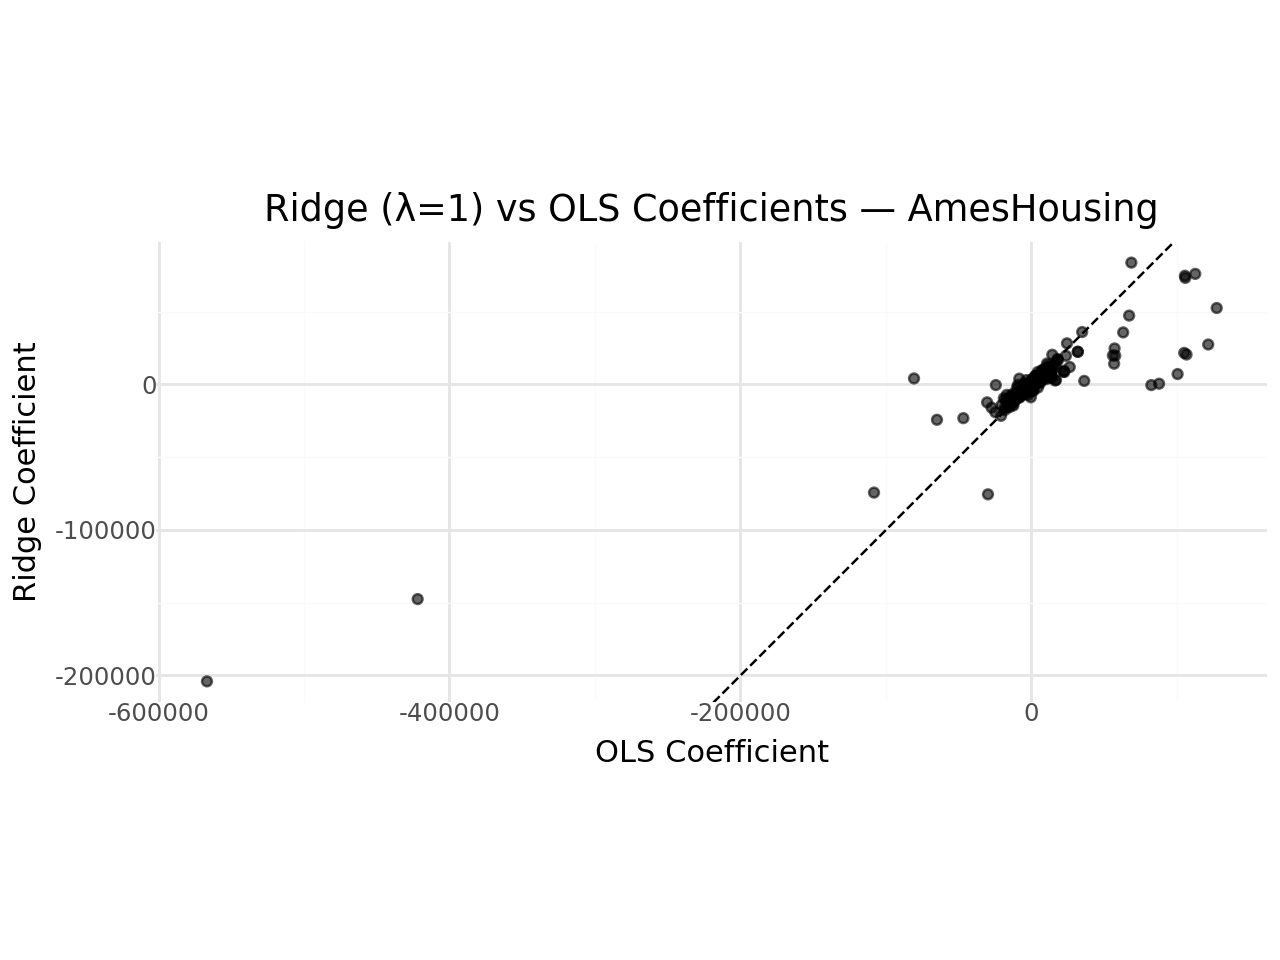

In [28]:
from plotnine import (
    ggplot, aes, geom_point, geom_abline, labs, theme_minimal,
    theme, element_text, coord_equal
)

p_coef = (
    ggplot(coef_df, aes(x="OLS", y="Ridge"))
    + geom_point(alpha=0.6)
    + geom_abline(slope=1, intercept=0, linetype="dashed")
    + coord_equal()
    + labs(
        title="Ridge (λ=1) vs OLS Coefficients — AmesHousing",
        x="OLS Coefficient",
        y="Ridge Coefficient"
    )
    + theme_minimal()
    + theme(plot_title=element_text(ha="center"))
)
p_coef


# PA 2: Tuning

In [31]:
alphas = np.logspace(-4, 3, 40)   # e.g., 0.0001 ... 1000

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": alphas},
    scoring="neg_root_mean_squared_error",  # RMSE (negated)
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)

print(f"Best λ (alpha): {grid.best_params_['model__alpha']:.5g}")
print(f"Best CV RMSE: {-grid.best_score_:.2f}")

Best λ (alpha): 10.608
Best CV RMSE: 27899.89


# PA 3: LASSO

In [ ]:
lasso_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=10000))
])

alphas = np.logspace(-4, 2, 30)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={"model__alpha": alphas},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

lasso_grid.fit(X, y)

print(f"Best λ (alpha): {lasso_grid.best_params_['model__alpha']:.5g}")
print(f"Best CV RMSE: {-lasso_grid.best_score_:.2f}")

In [ ]:
lasso_best = lasso_grid.best_estimator_
lasso_best.fit(X, y)

ridge = Ridge(alpha=1.0)
ols = LinearRegression()

ridge_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", ridge)
]).fit(X, y)

ols_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", ols)
]).fit(X, y)

feature_names = lasso_best.named_steps["preprocess"].get_feature_names_out()
lasso_coefs = lasso_best.named_steps["model"].coef_
ridge_coefs = ridge_pipe.named_steps["model"].coef_
ols_coefs   = ols_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "OLS": ols_coefs,
    "Ridge": ridge_coefs,
    "LASSO": lasso_coefs
})


# Elastic Net

In [ ]:
enet_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=10000))
])

alpha_grid = np.logspace(-4, 3, 40)          # λ
l1_grid    = np.linspace(0.05, 0.95, 10)     # α

param_grid = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_grid
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    enet_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:.2f}")

Comparing Coefficients:

In [ ]:

feature_names = enet_best.named_steps["preprocess"].get_feature_names_out()
enet_coefs  = enet_best.named_steps["model"].coef_
ridge_coefs = ridge_pipe.named_steps["model"].coef_
ols_coefs   = ols_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_coefs,
    "Ridge": ridge_coefs,
    "ElasticNet": enet_coefs
})


In [ ]:
from plotnine import (
    ggplot, aes, geom_point, geom_abline, coord_equal,
    labs, theme_minimal, theme, element_text
)

# Elastic Net vs Ridge
p_enet_ridge = (
    ggplot(coef_df, aes(x="Ridge", y="ElasticNet"))
    + geom_point(alpha=0.6)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="gray")
    + coord_equal()
    + labs(
        title="Elastic Net vs Ridge Coefficients (AmesHousing)",
        x="Ridge Coefficients",
        y="Elastic Net Coefficients"
    )
    + theme_minimal()
    + theme(plot_title=element_text(ha="center"))
)
p_enet_ridge
